In [1]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
import glob
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
DATA_PATH = r"C:\Users\Maten\Documents\projettellorosdataset\tello_data"

state_cols = [
    's_x', 's_y', 's_z',
    's_roll', 's_pitch', 's_yaw',
    's_vx', 's_vy', 's_vz'
]

# --- Colonnes commande u_t (4)
cmd_cols = [
    'u_ux', 'u_uy', 'u_uz', 'u_uyaw'
]

# --- Colonnes état suivant s_{t+1} (9)
next_state_cols = [
    'sp1_x', 'sp1_y', 'sp1_z',
    'sp1_roll', 'sp1_pitch', 'sp1_yaw',
    'sp1_vx', 'sp1_vy', 'sp1_vz'
]

input_cols = state_cols + cmd_cols
output_cols = next_state_cols


In [4]:
all_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))

if not all_files:
    raise FileNotFoundError(f"Aucun fichier CSV trouvé dans {DATA_PATH}")

print(f" {len(all_files)} fichiers CSV trouvés")

dfs = []

for file in all_files:
    df = pd.read_csv(file)

    # Vérification colonnes
    missing_inputs = set(input_cols) - set(df.columns)
    missing_outputs = set(output_cols) - set(df.columns)

    if missing_inputs or missing_outputs:
        print(f" Fichier ignoré : {os.path.basename(file)}")
        print("   Colonnes manquantes (input) :", missing_inputs)
        print("   Colonnes manquantes (output):", missing_outputs)
        continue

    # Nettoyage NaN → moyenne
    df = df.fillna(df.mean(numeric_only=True))
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)
print("Dataset total :", full_df.shape)


 9 fichiers CSV trouvés
Dataset total : (129748, 23)


In [5]:
X = full_df[input_cols].to_numpy()
Y = full_df[output_cols].to_numpy()

print("X shape :", X.shape)  # (N, 13)
print("Y shape :", Y.shape)  # (N, 9)


X shape : (129748, 13)
Y shape : (129748, 9)


In [6]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)


In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled,
    Y_scaled,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train :", X_train.shape, Y_train.shape)
print("Test  :", X_test.shape, Y_test.shape)


Train : (103798, 13) (103798, 9)
Test  : (25950, 13) (25950, 9)


In [9]:
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",      # "gpu_hist" si GPU NVIDIA
    objective="reg:squarederror",
    random_state=42
)

print(" Début entraînement XGBoost...")
model.fit(X_train, Y_train)
print(" Entraînement terminé")


 Début entraînement XGBoost...
 Entraînement terminé


In [10]:
Y_pred = model.predict(X_test)

rmse_global = np.sqrt(mean_squared_error(Y_test, Y_pred))
print(f"RMSE global (normalisé) : {rmse_global:.6f}")

print("\nRMSE par variable d'état :")
for i, col in enumerate(output_cols):
    rmse_i = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
    print(f"{col:10s} : {rmse_i:.6f}")


RMSE global (normalisé) : 0.050443

RMSE par variable d'état :
sp1_x      : 0.003517
sp1_y      : 0.004552
sp1_z      : 0.002505
sp1_roll   : 0.020164
sp1_pitch  : 0.051517
sp1_yaw    : 0.135344
sp1_vx     : 0.018570
sp1_vy     : 0.018195
sp1_vz     : 0.028403


In [11]:
Y_test_phys = scaler_Y.inverse_transform(Y_test)
Y_pred_phys = scaler_Y.inverse_transform(Y_pred)

rmse_phys = np.sqrt(mean_squared_error(Y_test_phys, Y_pred_phys))
print(f"RMSE global (physique) : {rmse_phys:.6f}")


RMSE global (physique) : 0.077981


In [12]:
MODEL_PATH = "xgboost_tello_dynamics.json"
model.save_model(MODEL_PATH)

# Sauvegarde des scalers
import joblib
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_Y, "scaler_Y.pkl")

print(" Modèle et scalers sauvegardés")


 Modèle et scalers sauvegardés


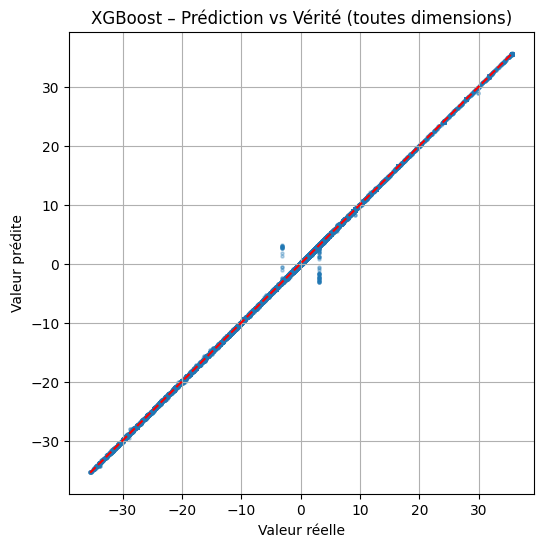

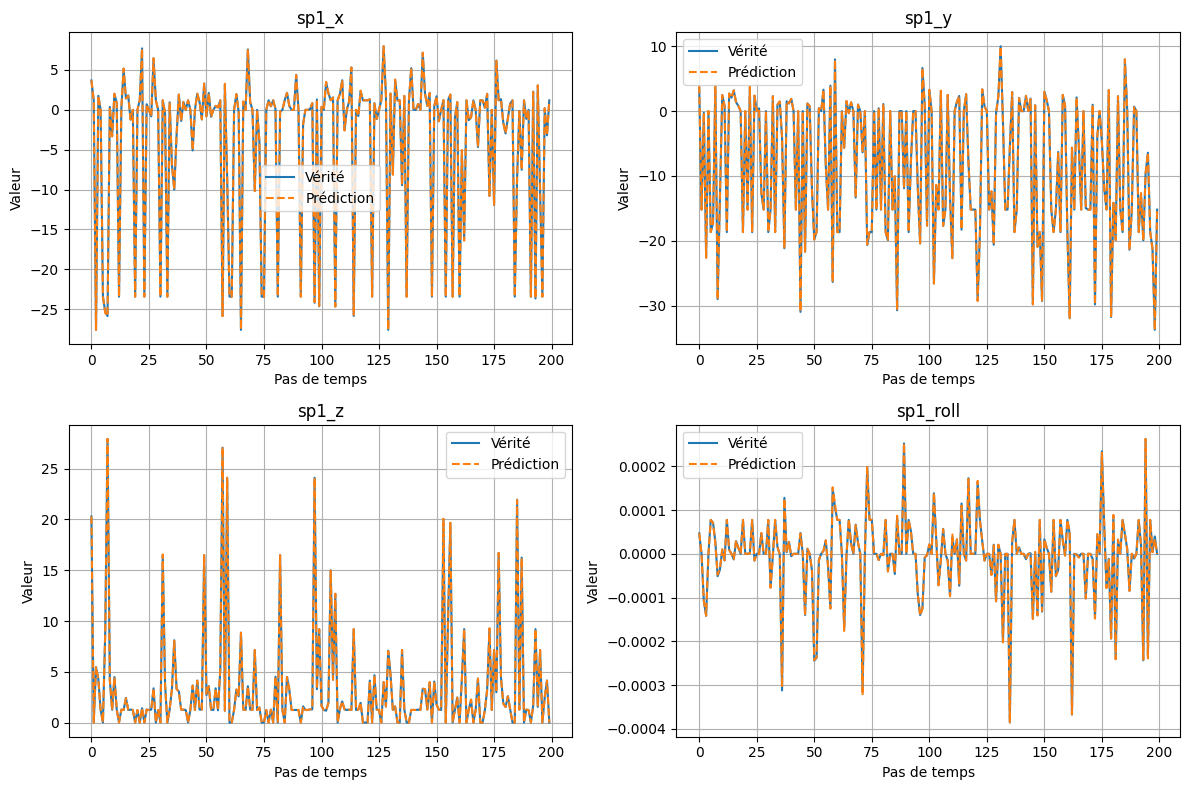

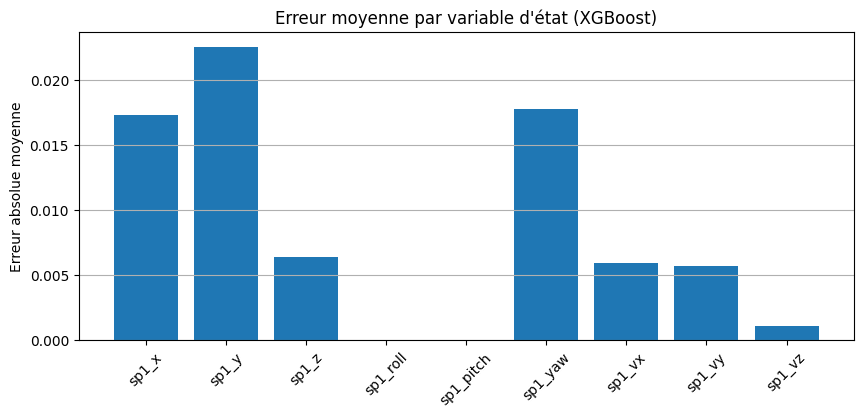

In [14]:
import matplotlib.pyplot as plt

# --------- 1) Scatter : prédiction vs vérité (dé-normalisé)
plt.figure(figsize=(6, 6))
plt.scatter(
    Y_test_phys.flatten(),
    Y_pred_phys.flatten(),
    s=5,
    alpha=0.3
)

min_val = min(Y_test_phys.min(), Y_pred_phys.min())
max_val = max(Y_test_phys.max(), Y_pred_phys.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Valeur réelle")
plt.ylabel("Valeur prédite")
plt.title("XGBoost – Prédiction vs Vérité (toutes dimensions)")
plt.grid(True)
plt.show()


# --------- 2) Courbes temporelles pour quelques états
n_plot = 200  # nombre de points affichés
t_idx = np.arange(n_plot)

state_labels = next_state_cols  # mêmes noms que dans le notebook

plt.figure(figsize=(12, 8))

for i, label in enumerate(state_labels[:4]):  # ex: x, y, z, roll
    plt.subplot(2, 2, i + 1)
    plt.plot(t_idx, Y_test_phys[:n_plot, i], label="Vérité")
    plt.plot(t_idx, Y_pred_phys[:n_plot, i], '--', label="Prédiction")
    plt.title(label)
    plt.xlabel("Pas de temps")
    plt.ylabel("Valeur")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


# --------- 3) Erreur absolue par variable d'état
abs_error = np.abs(Y_test_phys - Y_pred_phys)
mean_abs_error = abs_error.mean(axis=0)

plt.figure(figsize=(10, 4))
plt.bar(next_state_cols, mean_abs_error)
plt.xticks(rotation=45)
plt.ylabel("Erreur absolue moyenne")
plt.title("Erreur moyenne par variable d'état (XGBoost)")
plt.grid(axis='y')
plt.show()


In [16]:
import os

# Dossier de sauvegarde
save_dir = "figures_xgboost"
os.makedirs(save_dir, exist_ok=True)

# --------- 1) Scatter : prédiction vs vérité
plt.figure(figsize=(6, 6))
plt.scatter(
    Y_test_phys.flatten(),
    Y_pred_phys.flatten(),
    s=5,
    alpha=0.3
)

min_val = min(Y_test_phys.min(), Y_pred_phys.min())
max_val = max(Y_test_phys.max(), Y_pred_phys.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Valeur réelle")
plt.ylabel("Valeur prédite")
plt.title("XGBoost – Prédiction vs Vérité (toutes dimensions)")
plt.grid(True)

plt.savefig(os.path.join(save_dir, "scatter_prediction_vs_truth.png"), dpi=300, bbox_inches="tight")
plt.close()


# --------- 2) Courbes temporelles
n_plot = 200
t_idx = np.arange(n_plot)

plt.figure(figsize=(12, 8))

for i, label in enumerate(next_state_cols[:4]):
    plt.subplot(2, 2, i + 1)
    plt.plot(t_idx, Y_test_phys[:n_plot, i], label="Vérité")
    plt.plot(t_idx, Y_pred_phys[:n_plot, i], '--', label="Prédiction")
    plt.title(label)
    plt.xlabel("Pas de temps")
    plt.ylabel("Valeur")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "time_series_comparison.png"), dpi=300, bbox_inches="tight")
plt.close()


# --------- 3) Erreur absolue moyenne
abs_error = np.abs(Y_test_phys - Y_pred_phys)
mean_abs_error = abs_error.mean(axis=0)

plt.figure(figsize=(10, 4))
plt.bar(next_state_cols, mean_abs_error)
plt.xticks(rotation=45)
plt.ylabel("Erreur absolue moyenne")
plt.title("Erreur moyenne par variable d'état (XGBoost)")
plt.grid(axis='y')

plt.savefig(os.path.join(save_dir, "mean_absolute_error_per_state.png"), dpi=300, bbox_inches="tight")
plt.close()

print(f" Figures enregistrées dans le dossier : {save_dir}")


 Figures enregistrées dans le dossier : figures_xgboost
